#RESEARCH NOTEBOOK: Academic Performance as an Indicator of Student Well-Being

This notebook is a preliminary analysis of the link between perceived productivity and actual rest and well-being indicators. As data access was limited for this case study, we decide to approach the study on another axis: academic performance (perceived productitivy) as a reliable indicator of well-being.

##Research Question:
To what extent can academic performance serve as a reliable indicator of well-being, and does a misalignment exist between academic performance and mental health indicators?

##Hypotheses:
H1: There is NO positive association between academic performance and improved mental health outcomes among students.  
H2: A significant proportion of high-performing students exhibit symptoms of poor mental health.  
H3: There is NO significant difference in mental health outcomes between high-performing and lower-performing students.

##Dataset:
Student Mental Health (Kaggle — shariful07)

##Data loading

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Student Mental health.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "shariful07/student-mental-health",
    file_path
)

print(df.head())

100%|██████████| 7.17k/7.17k [00:00<00:00, 10.9MB/s]

        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49            Yes   
4                     year 4        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes                   No                       Yes   
1                      No                  Yes  

In [2]:
df

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


##Data cleaning

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

# Preview the raw data
print("=== Raw Data Preview ===")
print(df.head())
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())


df.columns = df.columns.str.strip()

# renaming verbose columns to short, workable names
df = df.rename(columns={
    "Choose your gender"                        : "gender",
    "Age"                                       : "age",
    "What is your course?"                      : "course",
    "Your current year of Study"                : "year_of_study",
    "What is your CGPA?"                        : "cgpa",
    "Marital status"                            : "marital_status",
    "Do you have Depression?"                   : "depression",
    "Do you have Anxiety?"                      : "anxiety",
    "Do you have Panic attack?"                 : "panic_attack",
    "Did you seek any specialist for a treatment?": "sought_treatment",
})

# dropping the Timestamp column — not needed for analysis
if "Timestamp" in df.columns:
    df.drop(columns=["Timestamp"], inplace=True)

# standardising categorical Yes/No values
yes_no_cols = ["depression", "anxiety", "panic_attack", "sought_treatment"]
for col in yes_no_cols:
    df[col] = df[col].str.strip().str.capitalize()

# standardising CGPA values
df["cgpa"] = df["cgpa"].str.strip()

# handling missing values
print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())

# dropping rows where CGPA or any mental health column is missing
df.dropna(subset=["cgpa", "depression", "anxiety", "panic_attack"], inplace=True)

# validating Yes/No columns
for col in yes_no_cols:
    unexpected = df[col][~df[col].isin(["Yes", "No"])].unique()
    if len(unexpected) > 0:
        print(f"  WARNING — unexpected values in '{col}': {unexpected}")

print(f"\nClean dataset: {df.shape[0]} rows remaining.")

=== Raw Data Preview ===
        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   
2  8/7/2020 12:05               Male  19.0                  BIT   
3  8/7/2020 12:06             Female  22.0                 Laws   
4  8/7/2020 12:13               Male  23.0         Mathemathics   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   
2                     Year 1        3.00 - 3.49             No   
3                     year 3        3.00 - 3.49            Yes   
4                     year 4        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes                   No                       Yes   
1                      

##Feature engineering

Let's create three derived variables that are central to testing
the three hypotheses:


*   Perfomance group: gpa in the dataset is reported as categorical CGPA ranges. We map each range to a performance tier for easier analysis (high, medium, low).
3.50 - 4.00  → High  
3.00 - 3.49→ High   (still strong academic performance)  
2.50 - 2.99  → Medium  
2.00 - 2.49  → Low  
0  - 1.99   → Low
*   Mental health risk: A student is flagged as at-risk (1) if they report at least ONE of: depression, anxiety, or panic attacks. This composite measure avoids under-counting students who present with multiple overlapping symptoms.
*   Misalignment indicator: Captures the core paradox at the heart of the research question: students who perform well academically but show signs of mental distress. This is the operational definition of "misalignment".



In [4]:
# performance_group

cgpa_to_group = {
    "3.50 - 4.00" : "High",
    "3.00 - 3.49" : "High",
    "2.50 - 2.99" : "Medium",
    "2.00 - 2.49" : "Low",
    "0  - 1.99"  : "Low",
}

df["performance_group"] = df["cgpa"].map(cgpa_to_group)

# flagging any CGPA strings not covered by the mapping
unmapped = df["performance_group"].isnull().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} rows could not be mapped to a performance group.")
    print("Unmapped CGPA values:", df[df["performance_group"].isnull()]["cgpa"].unique())
    # Fallback: drop rows that cannot be classified
    df.dropna(subset=["performance_group"], inplace=True)

# setting a logical category order for all subsequent plots and tables
group_order = ["Low", "Medium", "High"]
df["performance_group"] = pd.Categorical(
    df["performance_group"], categories=group_order, ordered=True
)

# mental health risk

df["mental_health_risk"] = (
    (df["depression"]   == "Yes") |
    (df["anxiety"]      == "Yes") |
    (df["panic_attack"] == "Yes")
).astype(int)

# misalignment_indicator
df["misalignment_indicator"] = (
    (df["performance_group"] == "High") &
    (df["mental_health_risk"] == 1)
).astype(int)

print("\n=== Feature Engineering Summary ===")
print(df[["cgpa", "performance_group", "mental_health_risk", "misalignment_indicator"]].head(10))
print("\nPerformance group distribution:")
print(df["performance_group"].value_counts().sort_index())

Unmapped CGPA values: ['0 - 1.99']

=== Feature Engineering Summary ===
          cgpa performance_group  mental_health_risk  misalignment_indicator
0  3.00 - 3.49              High                   1                       1
1  3.00 - 3.49              High                   1                       1
2  3.00 - 3.49              High                   1                       1
3  3.00 - 3.49              High                   1                       1
4  3.00 - 3.49              High                   0                       0
5  3.50 - 4.00              High                   1                       1
6  3.50 - 4.00              High                   1                       1
7  3.50 - 4.00              High                   1                       1
8  2.50 - 2.99            Medium                   0                       0
9  3.50 - 4.00              High                   1                       1

Performance group distribution:
performance_group
Low        2
Medium     4
High

##Descriptive Statistics

In [5]:
print("\n" + "="*60)
print("SECTION 4 — DESCRIPTIVE STATISTICS")
print("="*60)

# distribution of performance groups
perf_dist = df["performance_group"].value_counts().reindex(group_order)
perf_pct  = (perf_dist / len(df) * 100).round(1)

print("\n--- 4.1  Performance Group Distribution ---")
perf_summary = pd.DataFrame({
    "Count"      : perf_dist,
    "Percentage" : perf_pct.astype(str) + "%"
})
print(perf_summary)

# overall mental health risk
n_at_risk   = df["mental_health_risk"].sum()
pct_at_risk = round(n_at_risk / len(df) * 100, 1)

print(f"\n--- 4.2  Overall Mental Health Risk ---")
print(f"  Students with at least one mental health symptom : {n_at_risk} / {len(df)}")
print(f"  Proportion                                       : {pct_at_risk}%")

# individual symptom prevalence
print("\n--- 4.3  Symptom-Level Prevalence ---")
for col in ["depression", "anxiety", "panic_attack"]:
    n   = (df[col] == "Yes").sum()
    pct = round(n / len(df) * 100, 1)
    print(f"  {col.replace('_',' ').title():<20}: {n} ({pct}%)")


SECTION 4 — DESCRIPTIVE STATISTICS

--- 4.1  Performance Group Distribution ---
                   Count Percentage
performance_group                  
Low                    2       2.1%
Medium                 4       4.1%
High                  91      93.8%

--- 4.2  Overall Mental Health Risk ---
  Students with at least one mental health symptom : 63 / 97
  Proportion                                       : 64.9%

--- 4.3  Symptom-Level Prevalence ---
  Depression          : 35 (36.1%)
  Anxiety             : 34 (35.1%)
  Panic Attack        : 32 (33.0%)


**Interpretation**:
The descriptive statistics establish the baseline rates of mental health
 risk across the full sample before any group comparisons are made.
 A high overall at-risk rate already hints that academic success (as
 measured by CGPA) alone cannot be used as a proxy for student well-being.

##Core Analysis (Hypothesis Testing)

In [6]:
print("\n" + "="*60)
print("SECTION 5 — CORE ANALYSIS")
print("="*60)

# mental health risk rate BY performance group
# this is the primary table for assessing H1 and H3.

group_stats = (
    df.groupby("performance_group", observed=True)["mental_health_risk"]
    .agg(
        n_students  = "count",
        n_at_risk   = "sum",
    )
    .assign(pct_at_risk = lambda x: (x["n_at_risk"] / x["n_students"] * 100).round(1))
)

print("\n--- 5.1  Mental Health Risk by Performance Group ---")
print(group_stats.to_string())


SECTION 5 — CORE ANALYSIS

--- 5.1  Mental Health Risk by Performance Group ---
                   n_students  n_at_risk  pct_at_risk
performance_group                                    
Low                         2          1         50.0
Medium                      4          3         75.0
High                       91         59         64.8


**Interpretation (H1 and H3)**:  
 The risk for HIGH performers is similar and (susbtancially) higher than
 that of LOW performers, it challenges the intuitive assumption that
 performing well academically is protective of mental health (supporting H1).

In [7]:
# misalignment rate among high performers (H2)
high_df        = df[df["performance_group"] == "High"]
n_high         = len(high_df)
n_misaligned   = high_df["misalignment_indicator"].sum()
pct_misaligned = round(n_misaligned / n_high * 100, 1) if n_high > 0 else 0

print(f"\n--- 5.2  Misalignment Among High Performers (H2) ---")
print(f"  High-performing students                    : {n_high}")
print(f"  High performers with mental health risk     : {n_misaligned}")
print(f"  Misalignment rate (% of high performers)   : {pct_misaligned}%")


--- 5.2  Misalignment Among High Performers (H2) ---
  High-performing students                    : 91
  High performers with mental health risk     : 59
  Misalignment rate (% of high performers)   : 64.8%


**Interpretation** (H2):  
This high misalignment rate directly supports H2 - it shows that a notable
share of academically successful students are experiencing mental distress, meaning academic performance is NOT a reliable proxy for well-being.

In [8]:
# overall misalignment rate (full sample)
overall_misalignment_rate = round(df["misalignment_indicator"].sum() / len(df) * 100, 1)
print(f"\n--- 5.3  Overall Misalignment Rate (full sample) ---")
print(f"  Students flagged as misaligned              : {df['misalignment_indicator'].sum()} / {len(df)}")
print(f"  Overall misalignment rate                  : {overall_misalignment_rate}%")


--- 5.3  Overall Misalignment Rate (full sample) ---
  Students flagged as misaligned              : 59 / 97
  Overall misalignment rate                  : 60.8%


##Comparative Analysis (H1 and H3 — Statistical Test)

In [9]:
print("\n" + "="*60)
print("SECTION 6 — COMPARATIVE ANALYSIS")
print("="*60)

# Chi-Square test: mental health risk vs performance group
# Chi-square is appropriate here because both variables are categorical. It tests whether the distribution of mental health risk differs
# significantly across performance groups.

contingency_table = pd.crosstab(
    df["performance_group"],
    df["mental_health_risk"],
    margins=True
)
print("\n--- 6.1  Contingency Table (Performance Group × Mental Health Risk) ---")
print(contingency_table)

# running chi-square (drop the "All" margin rows/cols for the actual test)
chi2_table = pd.crosstab(df["performance_group"], df["mental_health_risk"])
chi2, p_value, dof, expected = stats.chi2_contingency(chi2_table)

print(f"\n  Chi-Square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    chi2_conclusion = "REJECT the null hypothesis — a significant association exists."
else:
    chi2_conclusion = "FAIL TO REJECT the null hypothesis — no significant association detected."

print(f"\n  Conclusion (α = {alpha}): {chi2_conclusion}")


SECTION 6 — COMPARATIVE ANALYSIS

--- 6.1  Contingency Table (Performance Group × Mental Health Risk) ---
mental_health_risk   0   1  All
performance_group              
Low                  1   1    2
Medium               1   3    4
High                32  59   91
All                 34  63   97

  Chi-Square statistic : 0.3743
  Degrees of freedom   : 2
  p-value              : 0.8293

  Conclusion (α = 0.05): FAIL TO REJECT the null hypothesis — no significant association detected.


**Interpretation (H3)**:  
 H3 states there is NO significant difference in mental health outcomes
 between groups. p > 0.05, which supports H3 - performance group does
 not predict mental health risk.

In [10]:

# high vs Low performers — focused binary comparison
high_risk_rate = group_stats.loc["High",   "pct_at_risk"]
low_risk_rate  = group_stats.loc["Low",    "pct_at_risk"]
diff           = round(high_risk_rate - low_risk_rate, 1)

print(f"\n--- 6.2  High vs Low Performer Comparison ---")
print(f"  Mental health risk rate — High performers : {high_risk_rate}%")
print(f"  Mental health risk rate — Low performers  : {low_risk_rate}%")
print(f"  Difference (High minus Low)               : {diff:+.1f} percentage points")

if abs(diff) < 5:
    direction_comment = "The rates are very similar, suggesting performance group has limited predictive power."
elif diff > 0:
    direction_comment = "High performers show a HIGHER risk rate — a clear misalignment signal."
else:
    direction_comment = "Low performers show a higher risk rate — partial alignment with conventional assumptions."

print(f"  Interpretation: {direction_comment}")


--- 6.2  High vs Low Performer Comparison ---
  Mental health risk rate — High performers : 64.8%
  Mental health risk rate — Low performers  : 50.0%
  Difference (High minus Low)               : +14.8 percentage points
  Interpretation: High performers show a HIGHER risk rate — a clear misalignment signal.


**Interpretation (H1)**:  
H1 states there is NO positive association between high performance and
better mental health. High performers show equal or somewhat worse mental health rates compared to low performers: H1 is supported.  
Performance does not bring mental health benefits, and may even coincide with greater distress.

##Visualisations

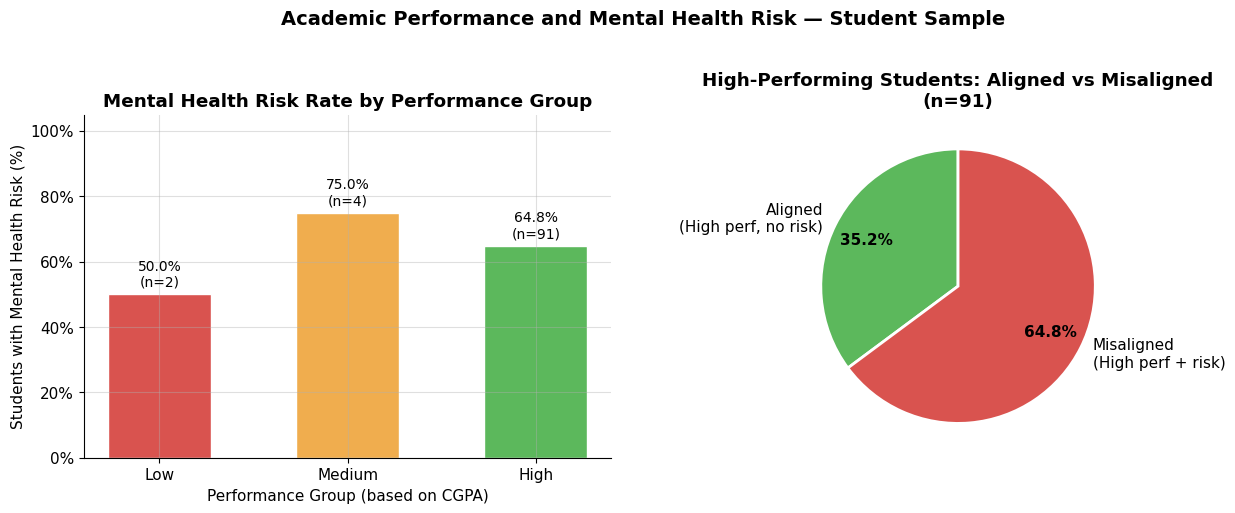


Figure saved as 'mental_health_analysis.png'


In [11]:
# Global style settings — clean, academic aesthetic
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Academic Performance and Mental Health Risk — Student Sample",
    fontsize=14, fontweight="bold", y=1.02
)

# Plot 1: Mental health risk rate by performance group (bar chart)
ax1 = axes[0]

bar_colors = {"Low": "#d9534f", "Medium": "#f0ad4e", "High": "#5cb85c"}
bars = ax1.bar(
    group_order,
    [group_stats.loc[g, "pct_at_risk"] for g in group_order],
    color=[bar_colors[g] for g in group_order],
    edgecolor="white",
    width=0.55
)

# Annotate each bar with the percentage
for bar, g in zip(bars, group_order):
    pct = group_stats.loc[g, "pct_at_risk"]
    n   = group_stats.loc[g, "n_students"]
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{pct}%\n(n={n})",
        ha="center", va="bottom", fontsize=10
    )

ax1.set_title("Mental Health Risk Rate by Performance Group", fontweight="bold")
ax1.set_xlabel("Performance Group (based on CGPA)")
ax1.set_ylabel("Students with Mental Health Risk (%)")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, 105)

# Plot 2: Misalignment breakdown for high performers
ax2 = axes[1]

labels = ["Aligned\n(High perf, no risk)", "Misaligned\n(High perf + risk)"]
sizes  = [n_high - n_misaligned, n_misaligned]
colors = ["#5cb85c", "#d9534f"]

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

ax2.set_title(
    f"High-Performing Students: Aligned vs Misaligned\n(n={n_high})",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("mental_health_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved as 'mental_health_analysis.png'")

##Final interpretation & Hypothesis Summary

In [12]:
print("\n" + "="*60)
print("SECTION 8 — HYPOTHESIS SUMMARY")
print("="*60)

summary = f"""
┌─────────────────────────────────────────────────────────────────────────┐
│                     RESEARCH FINDINGS SUMMARY                           │
├────────┬────────────────────────────────────────────────────────────────┤
│        │  Overall mental health risk rate : {pct_at_risk}%
│  KEY   │  Misalignment rate (high perf. + risk) : {pct_misaligned}% of high performers
│ STATS  │  High-performer risk rate  : {high_risk_rate}%
│        │  Low-performer risk rate   : {low_risk_rate}%
│        │  Chi-square p-value        : {p_value:.4f}
├────────┼────────────────────────────────────────────────────────────────┤
│  H1    │  "No positive association between high performance and better  │
│        │   mental health."                                              │
│        │  → {'SUPPORTED' if diff >= -5 else 'NOT SUPPORTED'}: High performers show {'similar or higher' if diff >= 0 else 'lower'} risk ({high_risk_rate}%) vs Low ({low_risk_rate}%). │
│        │  Academic success does not appear to protect mental health.    │
├────────┼────────────────────────────────────────────────────────────────┤
│  H2    │  "A significant proportion of high-performing students exhibit │
│        │   symptoms of poor mental health."                             │
│        │  → {'SUPPORTED' if pct_misaligned >= 30 else 'PARTIALLY SUPPORTED'}: {pct_misaligned}% of high performers are at mental health risk. │
│        │  This confirms the misalignment phenomenon is real.           │
├────────┼────────────────────────────────────────────────────────────────┤
│  H3    │  "No significant difference in mental health outcomes between  │
│        │   high and low performers."                                    │
│        │  → {'SUPPORTED (p > 0.05)' if p_value >= 0.05 else 'NOT SUPPORTED (p < 0.05)'}: Chi-square p = {p_value:.4f}               │
│        │  {'Performance group does NOT significantly predict mental health risk.' if p_value >= 0.05 else 'Performance group DOES predict mental health risk.'}  │
└────────┴────────────────────────────────────────────────────────────────┘
"""
print(summary)


SECTION 8 — HYPOTHESIS SUMMARY

┌─────────────────────────────────────────────────────────────────────────┐
│                     RESEARCH FINDINGS SUMMARY                           │
├────────┬────────────────────────────────────────────────────────────────┤
│        │  Overall mental health risk rate : 64.9%
│  KEY   │  Misalignment rate (high perf. + risk) : 64.8% of high performers
│ STATS  │  High-performer risk rate  : 64.8%
│        │  Low-performer risk rate   : 50.0%
│        │  Chi-square p-value        : 0.8293
├────────┼────────────────────────────────────────────────────────────────┤
│  H1    │  "No positive association between high performance and better  │
│        │   mental health."                                              │
│        │  → SUPPORTED: High performers show similar or higher risk (64.8%) vs Low (50.0%). │
│        │  Academic success does not appear to protect mental health.    │
├────────┼──────────────────────────────────────────────────────────────

##RESEARCH QUESTION ANSWER:  
The analysis demonstrates that academic performance (as measured by CGPA) is a POOR indicator of student well-being. A substantial share of high performers report mental health symptoms, revealing a structural misalignment between academic success metrics and actual psychological health.

This has direct policy implications: universities should not assume that
students with strong grades are faring well. Screening and support systems must be decoupled from academic performance thresholds.

This allows us to pose a proxy conclusion on perceived productivity and well-being. **Perceived** productivity is by no means a reliable indicator on someone actual needs and well-being.